# Regression using SciKitLearn
In this tutorial we are going to use an already clean dataset from the [Nomadlist Cities](https://nomadlist.com/) data to predict the continent where the city is located.

We are using [ScikitLearn library](https://scikit-learn.org/stable/index.html)

In [1]:
# Import standard Libraries
import pandas as pd
import seaborn as sns
import altair as alt
import matplotlib.pyplot as plt


sns.set(rc={'figure.figsize':(10,10)})
print("imports ok")

pd.set_option("display.float_format", "{:.3f}".format)

imports ok


In [2]:
# Load data

data = pd.read_csv('C:\\Users\\DD\\Desktop\\IAAC\\DATA encoding\\final project_entropy prediction\\data\\processed\\dataset_dropped_features_clean.csv')
pd.options.display.max_columns = None

print(data)

      entropy_normalised  n_3way  n_deadend  proportion_4way  proportion_3way  \
0                  0.444     109          7            0.604            0.337   
1                  0.429     141          5            0.191            0.770   
2                  0.390      72          0            0.684            0.285   
3                  0.422     115          8            0.662            0.280   
4                  0.395     111          3            0.680            0.291   
...                  ...     ...        ...              ...              ...   
2495               0.946     112         49            0.104            0.531   
2496               0.971      80         12            0.441            0.379   
2497               0.954     163         15            0.120            0.700   
2498               0.973     106          9            0.075            0.721   
2499               0.951      59         15            0.139            0.584   

      proportion_deadend  m

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   entropy_normalised     2500 non-null   float64
 1   n_3way                 2500 non-null   int64  
 2   n_deadend              2500 non-null   int64  
 3   proportion_4way        2500 non-null   float64
 4   proportion_3way        2500 non-null   float64
 5   proportion_deadend     2500 non-null   float64
 6   mean_edge_length       2500 non-null   float64
 7   total_edge_length      2500 non-null   float64
 8   circuity               2500 non-null   float64
 9   distance_to_center_km  2500 non-null   float64
dtypes: float64(8), int64(2)
memory usage: 195.4 KB


## Predicting the Nomad Score


Prepare data

In [4]:
# Select the (independant) features that we are going to use to train the model

feature_cols = ['n_3way', 'n_deadend', 'proportion_4way', 'proportion_3way',
                'proportion_deadend', 'mean_edge_length', 'total_edge_length',
                'circuity', 'distance_to_center_km']

X = data[feature_cols]
X


,n_3way,n_deadend,proportion_4way,proportion_3way,proportion_deadend,mean_edge_length,total_edge_length,circuity,distance_to_center_km
0,109,7,0.604,0.337,0.022,38.810,22082.510,1.007,20.043
1,141,5,0.191,0.770,0.027,26.780,7659.620,1.012,5.766
2,72,0,0.684,0.285,0.000,41.820,19322.010,1.005,15.597
3,115,8,0.662,0.280,0.019,40.530,30157.710,1.014,13.427
4,111,3,0.680,0.291,0.008,41.050,28486.590,1.001,16.712
...,...,...,...,...,...,...,...,...,...
2495,112,49,0.104,0.531,0.232,46.210,12430.890,1.036,3.083
2496,80,12,0.441,0.379,0.057,52.540,17914.620,1.020,7.264
2497,163,15,0.120,0.700,0.064,49.490,16579.580,1.085,6.121
2498,106,9,0.075,0.721,0.061,59.740,12426.820,1.131,11.208


In [5]:
# Load and instantiate a StandardSclaer
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

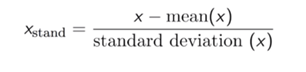

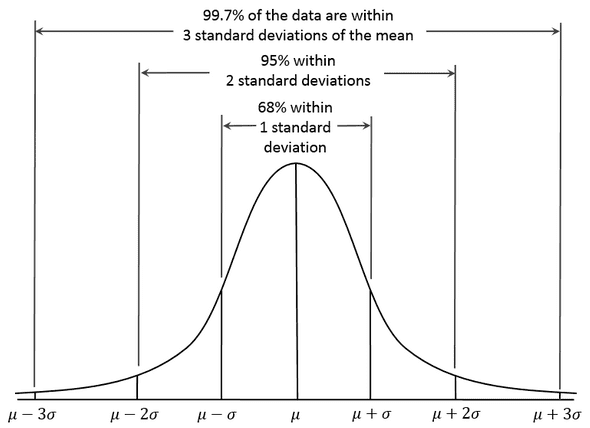

In [6]:
# Apply the scaler to our X-features
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.04573158, -0.74104554,  2.18501905, ...,  0.99808274,
        -0.85544509,  0.74285456],
       [ 0.41958464, -0.79500334, -0.13697384, ..., -0.83401876,
        -0.74948792, -0.63830259],
       [-0.38653603, -0.92989782,  2.63583554, ...,  0.64742374,
        -0.87902891,  0.31274846],
       ...,
       [ 0.67660862, -0.52521437, -0.53715729, ...,  0.29906013,
         0.70320745, -0.60395989],
       [ 0.01068285, -0.68708775, -0.79241674, ..., -0.22845397,
         1.62601697, -0.11184345],
       [-0.53841384, -0.52521437, -0.43333534, ..., -0.56428126,
        -0.17339458, -0.53014726]], shape=(2500, 9))

In [7]:
print(X_scaled.shape)
tdf = pd.DataFrame(X_scaled)

#print(type(X_scaled))
print(tdf.describe())

(2500, 9)
             0        1        2        3        4        5        6        7  \
count 2500.000 2500.000 2500.000 2500.000 2500.000 2500.000 2500.000 2500.000   
mean     0.000    0.000   -0.000   -0.000    0.000    0.000    0.000    0.000   
std      1.000    1.000    1.000    1.000    1.000    1.000    1.000    1.000   
min     -1.123   -0.930   -1.214   -3.242   -1.658   -1.912   -1.718   -1.023   
25%     -0.679   -0.606   -0.745   -0.613   -0.777   -0.771   -0.762   -0.660   
50%     -0.223   -0.309   -0.294    0.044   -0.110   -0.221   -0.202   -0.256   
75%      0.373    0.237    0.433    0.671    0.664    0.528    0.619    0.293   
max      9.065   11.184    2.997    3.603    3.522    5.239    3.242    7.934   

             8  
count 2500.000  
mean    -0.000  
std      1.000  
min     -1.165  
25%     -0.629  
50%     -0.251  
75%      0.229  
max      6.368  


In [8]:
# Define the dependant variable / target to predict

y_reg = data['entropy_normalised']
print(y_reg)


0      0.444
1      0.429
2      0.390
3      0.422
4      0.395
        ... 
2495   0.946
2496   0.971
2497   0.954
2498   0.973
2499   0.951
Name: entropy_normalised, Length: 2500, dtype: float64


In [9]:
#Split the data using the train_test_split module. We keep 20% of the data for testing and use 80% to train the model
# Random state defined with an arbitrary number for reproducibility

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, data_train, data_test = train_test_split(X_scaled, y_reg, data, test_size = 0.2, random_state = 42)

In [10]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(2000, 9)
(2000,)
(500, 9)
(500,)


Train model

In [ ]:
# Import and instantiate the baseline model
from sklearn.linear_model import Ridge
model = Ridge(alpha=1.0)


# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is R^2
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.4553862870588776
0.4867496556793395


In [12]:
print("Coefficient", model.coef_, "intercetp",  model.intercept_)

Coefficient [ 0.04253469 -0.01834106 -0.14782858 -0.03889447 -0.00414897 -0.02658486
 -0.00108164  0.02473205 -0.01773207] intercetp 0.6918832601082847


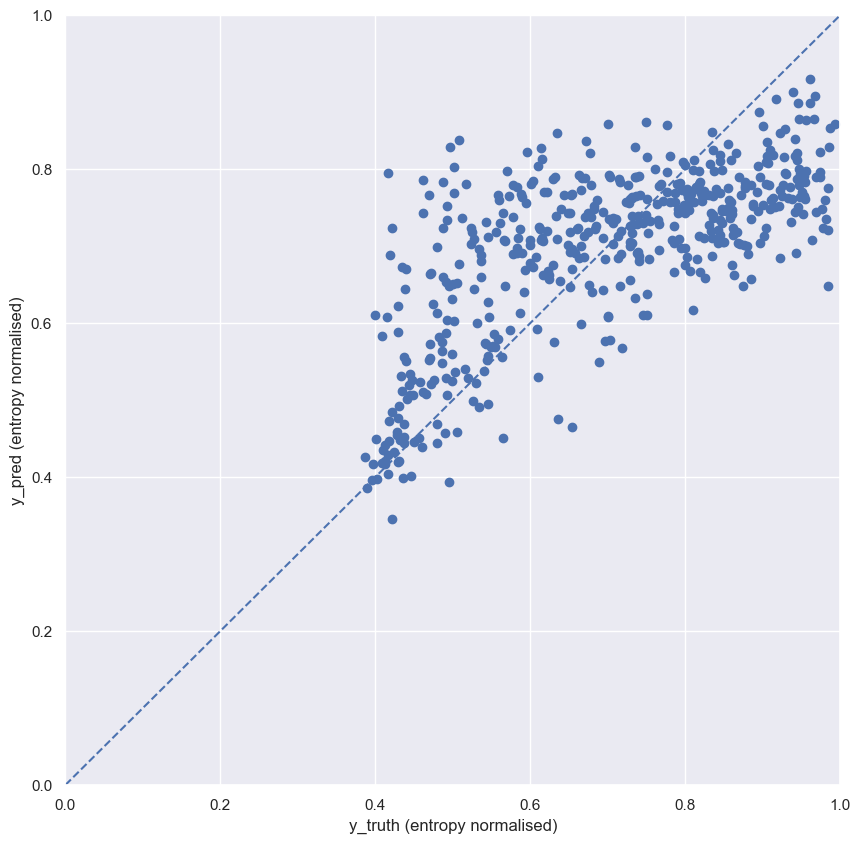

In [13]:
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)

plt.xlabel("y_truth (entropy normalised)")
plt.ylabel("y_pred (entropy normalised)")
plt.ylim((0, 1))
plt.xlim((0, 1))
plt.axline((0, 0), slope=1, ls="--")


In [14]:
data_test.info()

<class 'pandas.DataFrame'>
Index: 500 entries, 1447 to 2213
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   entropy_normalised     500 non-null    float64
 1   n_3way                 500 non-null    int64  
 2   n_deadend              500 non-null    int64  
 3   proportion_4way        500 non-null    float64
 4   proportion_3way        500 non-null    float64
 5   proportion_deadend     500 non-null    float64
 6   mean_edge_length       500 non-null    float64
 7   total_edge_length      500 non-null    float64
 8   circuity               500 non-null    float64
 9   distance_to_center_km  500 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 43.0 KB


XG boost

In [ ]:
# Import and instantiate a XGBoost Regressor
import xgboost as xgb
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=3,          # default 6 — too deep, causes overfitting
    learning_rate=0.05,   # default 0.3 — slower but better
    subsample=0.8,        # use 80% of rows per tree
    colsample_bytree=0.8, # use 80% of features per tree
    reg_alpha=0.1,        # L1 regularization
    reg_lambda=1.0,       # L2 regularization
    random_state=42
)


# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is not accacy but a R^2
print(model.score(X_test, y_test))
print(model.score(X_train, y_train))

0.4635794670980017
0.9866790162452512


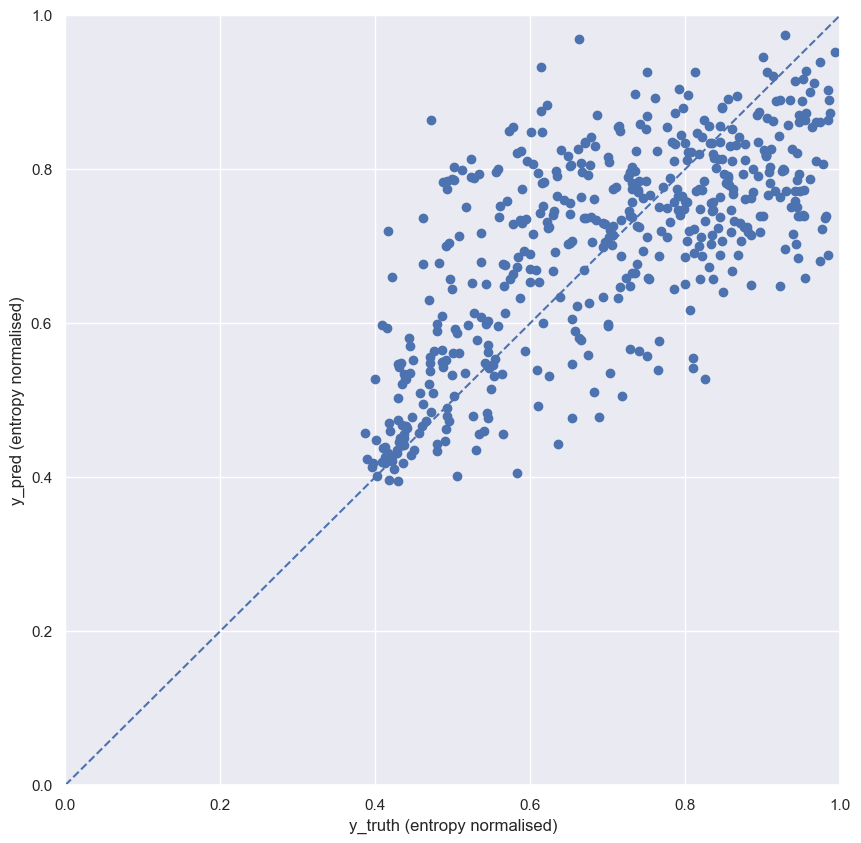

In [16]:
# We can also inspect our results visually
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)

plt.xlabel("y_truth (entropy normalised)")
plt.ylabel("y_pred (entropy normalised)")
plt.ylim((0, 1))
plt.xlim((0, 1))
plt.axline((0, 0), slope=1, ls="--")


Random forest

0.9269282971526513
0.5224048846436076


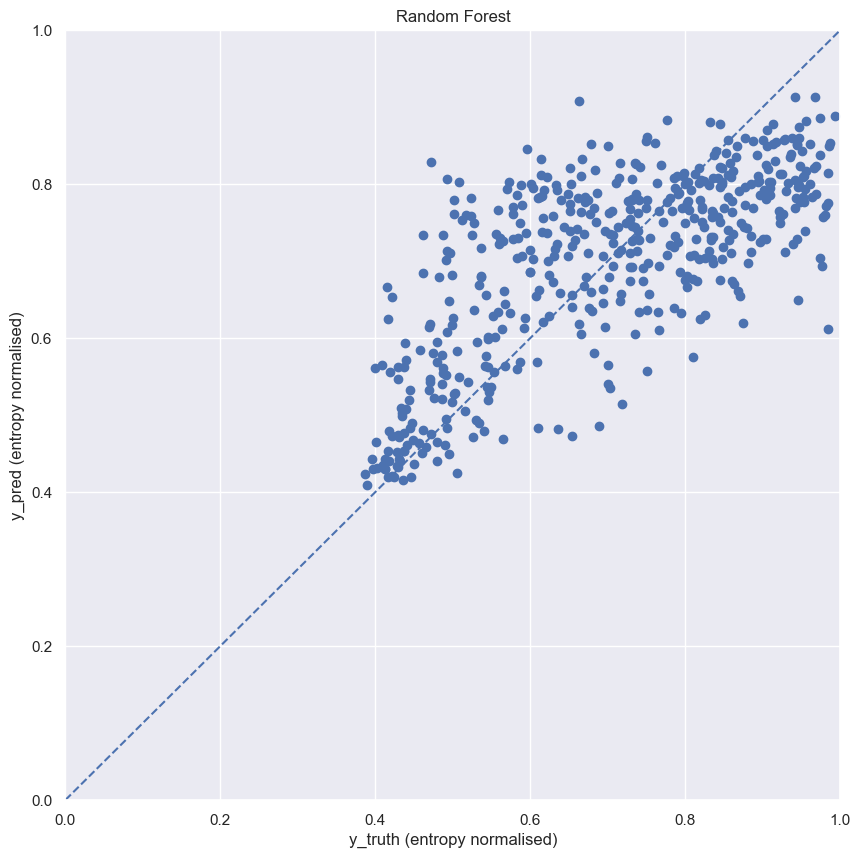

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,           # prevent overfitting
    min_samples_leaf=5,    # each leaf needs at least 5 samples
    random_state=42
)


model_rf.fit(X_train, y_train)

print(model_rf.score(X_train, y_train))
print(model_rf.score(X_test, y_test))

y_pred_rf = model_rf.predict(X_test)

plt.scatter(y_test, y_pred_rf)
plt.xlabel("y_truth (entropy normalised)")
plt.ylabel("y_pred (entropy normalised)")
plt.ylim((0, 1))
plt.xlim((0, 1))
plt.axline((0, 0), slope=1, ls="--")
plt.title("Random Forest")
plt.show()